# CV Analysis — Random Forest Model
**Profile Matching** : Binary (Fit vs No Fit) — XGBoost/RF Classifier
**ATS Scoring**      : 3-class (Low/Medium/High) — XGBoost/RF Classifier + SMOTE
**Section Scoring**  : Regression 0–100 — XGBoost/RF Multi-output Regressor

## 1. Installation & Imports

In [ ]:
!pip install -q sentence-transformers datasets xgboost scikit-learn imbalanced-learn \
    matplotlib seaborn tabulate numpy pandas joblib optuna

import os, re, json, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import torch
import optuna
from tabulate import tabulate
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
)
from xgboost import XGBClassifier, XGBRegressor
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Config

In [ ]:
SEED = 42
np.random.seed(SEED)
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

@dataclass
class Config:
    test_size:                  float = 0.20
    match_confidence_threshold: float = 0.50
    grade_excellent:            int   = 80
    grade_good:                 int   = 60
    grade_fair:                 int   = 40
    weight_section_overall:     float = 0.60
    weight_ats:                 float = 0.40
    optuna_trials:              int   = 30
    pca_components:             int   = 128
    section_keywords:           dict  = None
    cliches:                    list  = None

    def __post_init__(self):
        if self.section_keywords is None:
            self.section_keywords = {
                "has_summary":    ["summary", "profile", "about", "objective"],
                "has_skills":     ["skills", "expertise", "competencies", "technical"],
                "has_experience": ["experience", "employment", "work history"],
                "has_education":  ["education", "academic", "qualification", "degree"],
            }
        if self.cliches is None:
            self.cliches = [
                "team player", "hard-working", "go-getter", "self-starter",
                "detail-oriented", "results-oriented", "passionate about",
            ]

CFG            = Config()
MATCH_LABEL    = {0: "No Fit", 1: "Fit"}
ATS_LABEL      = {0: "Low ATS", 1: "Medium ATS", 2: "High ATS"}
TARGET_COLS    = ["score_experience", "score_skills", "score_education", "score_overall"]

print(f"Device         : {DEVICE}")
print(f"Models         : {MODEL_DIR.resolve()}")
print(f"test_size      : {CFG.test_size}")
print(f"pca_components : {CFG.pca_components}")
print(f"optuna_trials  : {CFG.optuna_trials}")

Device         : cuda
Models         : /content/models
test_size      : 0.2
pca_components : 128
optuna_trials  : 30


## 3. Encoder

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"GPU detected: {torch.cuda.get_device_name(0)}" if DEVICE == "cuda" else "No GPU detected, using CPU.")

encoder = SentenceTransformer(
    "nomic-ai/nomic-embed-text-v1", trust_remote_code=True, device=DEVICE
)

if DEVICE == "cuda":
    encoder = encoder.half()

encoder.max_seq_length = 512

def encode_texts(texts: List[str], batch_size: int = 64,
                 prefix: str = "search_document") -> np.ndarray:
    prefixed = [f"{prefix}: {t}" for t in texts]
    bs = batch_size
    while True:
        try:
            return encoder.encode(
                prefixed, batch_size=bs, show_progress_bar=True,
                normalize_embeddings=True, convert_to_numpy=True,
            )
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            bs = bs // 2
            if bs < 1:
                raise
            print(f"[warn] CUDA OOM, retrying with batch_size={bs}")

def build_pair_features(emb_a: np.ndarray, emb_b: np.ndarray) -> np.ndarray:
    cos  = (emb_a * emb_b).sum(axis=1, keepdims=True)
    diff = np.abs(emb_a - emb_b)
    prod = emb_a * emb_b
    return np.hstack([cos, diff, prod])

print(f"Encoder loaded on {DEVICE.upper()} (fp16={DEVICE=='cuda'}).")

GPU detected: Tesla T4


Encoder loaded on CUDA (fp16=True).


## 4. Feature Extractors

In [ ]:
def extract_ats_features(text: str) -> Dict[str, float]:
    t     = text.lower()
    words = text.split()
    wc    = len(words)
    feats = {}
    for key, kws in CFG.section_keywords.items():
        feats[key] = int(any(k in t for k in kws))
    feats["has_email"]    = int(bool(re.search(r"[\w.+-]+@[\w-]+\.[a-z]{2,}", text)))
    feats["has_phone"]    = int(bool(re.search(r"\+?\d[\d\s\-\.\(\)]{6,}\d", text)))
    feats["has_dates"]    = int(bool(re.search(r"\b(19|20)\d{2}\b", text)))
    feats["has_metrics"]  = int(bool(re.search(
        r"\d+\s*(%|percent|users|clients|revenue|saving|increase|decrease)", t)))
    feats["has_bullets"]  = int(bool(re.search(r"^[•\-\*]", text, re.MULTILINE)))
    feats["no_cliches"]   = int(not any(c in t for c in CFG.cliches))
    feats["word_count"]   = wc
    feats["wc_optimal"]   = int(300 <= wc <= 800)
    feats["wc_too_short"] = int(wc < 200)
    feats["wc_too_long"]  = int(wc > 1200)
    feats["unique_ratio"] = len(set(words)) / max(wc, 1)
    feats["avg_word_len"] = float(np.mean([len(w) for w in words])) if words else 0.0
    return feats

def extract_explicit_features(resume: str, jd: str) -> np.ndarray:
    r_lower = resume.lower()
    j_lower = jd.lower()
    r_words = set(r_lower.split())
    j_words = set(j_lower.split())
    overlap        = len(r_words & j_words) / max(len(j_words), 1)
    len_ratio      = min(len(resume), len(jd)) / max(max(len(resume), len(jd)), 1)
    has_email      = int(bool(re.search(r"[\w.+-]+@[\w-]+\.[a-z]{2,}", resume)))
    has_phone      = int(bool(re.search(r"\+?\d[\d\s\-\.\(\)]{6,}\d", resume)))
    has_dates      = int(bool(re.search(r"\b(19|20)\d{2}\b", resume)))
    has_skills_kw  = int(any(k in r_lower for k in ["skills", "expertise", "proficient"]))
    has_exp_kw     = int(any(k in r_lower for k in ["experience", "worked", "developed"]))
    has_edu_kw     = int(any(k in r_lower for k in ["education", "degree", "university"]))
    has_metrics    = int(bool(re.search(
        r"\d+\s*(%|percent|users|clients|revenue|saving|increase|decrease)", r_lower)))
    r_word_count   = min(len(resume.split()) / 1000, 1.0)
    return np.array([overlap, len_ratio, has_email, has_phone, has_dates,
                     has_skills_kw, has_exp_kw, has_edu_kw, has_metrics, r_word_count])

print("Feature extractors ready.")

Feature extractors ready.


## 5. Dataset 1 — Profile Matching

In [ ]:
ds_match = load_dataset("cnamuangtoun/resume-job-description-fit")
df_match  = pd.concat([
    ds_match["train"].to_pandas(),
    ds_match["test"].to_pandas(),
]).reset_index(drop=True)

df_match = df_match.dropna(subset=["resume_text", "job_description_text", "label"])
df_match["resume_text"]          = df_match["resume_text"].str.strip()
df_match["job_description_text"] = df_match["job_description_text"].str.strip()
df_match["label"]                = df_match["label"].str.strip().str.title()

label_map             = {"Good Fit": 1, "Potential Fit": 1, "No Fit": 0}
df_match["label_enc"] = df_match["label"].map(label_map)
df_match = df_match.dropna(subset=["label_enc"]).reset_index(drop=True)
df_match["label_enc"] = df_match["label_enc"].astype(int)

print("=" * 55)
print("  DATASET 1 — Profile Matching (Binary)")
print("=" * 55)
print(f"  Source : cnamuangtoun/resume-job-description-fit")
print(f"  Rows   : {len(df_match)}")
dist = df_match["label_enc"].value_counts().sort_index()
for k, v in dist.items():
    print(f"  {MATCH_LABEL[k]:<10} : {v} samples")
print()
print(df_match[["resume_text", "job_description_text", "label"]].head(2).to_string())

  DATASET 1 — Profile Matching (Binary)
  Source : cnamuangtoun/resume-job-description-fit
  Rows   : 8000
  No Fit     : 4000 samples
  Fit        : 4000 samples

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

## 6. Dataset 2 — ATS Scoring

In [ ]:
ds_ats = load_dataset("0xnbk/resume-ats-score-v1-en")
df_ats = ds_ats["train"].to_pandas().dropna(subset=["text", "ats_score"])

def split_sep(text: str) -> Tuple[str, str]:
    parts = str(text).split(" SEP ", 1)
    return (parts[0].strip(), parts[1].strip()) if len(parts) == 2 else (parts[0].strip(), "")

df_ats[["resume", "job"]] = df_ats["text"].apply(lambda x: pd.Series(split_sep(x)))
df_ats["ats_score"]       = pd.to_numeric(df_ats["ats_score"], errors="coerce")
df_ats = df_ats.dropna(subset=["ats_score"])
df_ats = df_ats[df_ats["resume"].str.len() > 50].reset_index(drop=True)

def bin_ats(score):
    if score < 40: return 0
    if score < 65: return 1
    return 2

df_ats["ats_class"] = df_ats["ats_score"].apply(bin_ats)

print("=" * 55)
print("  DATASET 2 — ATS Scoring (3-class)")
print("=" * 55)
print(f"  Source : 0xnbk/resume-ats-score-v1-en")
print(f"  Rows   : {len(df_ats)}")
print(f"  Score  : mean={df_ats['ats_score'].mean():.2f} | "
      f"min={df_ats['ats_score'].min():.1f} | max={df_ats['ats_score'].max():.1f}")
for k, v in ATS_LABEL.items():
    mask = df_ats["ats_class"] == k
    print(f"  {v:<15}: {mask.sum()} samples | "
          f"{df_ats[mask]['ats_score'].min():.1f}–{df_ats[mask]['ats_score'].max():.1f}")
print()
print(df_ats[["resume", "ats_score", "ats_class"]].head(2).to_string())

  DATASET 2 — ATS Scoring (3-class)
  Source : 0xnbk/resume-ats-score-v1-en
  Rows   : 5098
  Score  : mean=47.19 | min=19.2 | max=90.0
  Low ATS        : 2565 samples | 19.2–30.3
  Medium ATS     : 1272 samples | 50.0–60.4
  High ATS       : 1261 samples | 78.7–90.0

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

## 7. Dataset 3 — Section Scoring (Synthetic)

In [ ]:
def extract_section(text: str, keywords: List[str]) -> str:
    t_lower = text.lower()
    for kw in keywords:
        idx = t_lower.find(kw)
        if idx != -1:
            return text[idx:idx + 500].strip()
    return text[:300].strip()

SECTION_DEFS = {
    "experience": ["experience", "work experience", "employment history"],
    "skills":     ["skills", "technical skills", "expertise", "competencies"],
    "education":  ["education", "academic", "qualification", "degree"],
}

records = []
for _, row in df_match.iterrows():
    record = {"resume": row["resume_text"], "jd": row["job_description_text"]}
    for section, kws in SECTION_DEFS.items():
        record[f"section_{section}"] = extract_section(row["resume_text"], kws)
    records.append(record)

df_section_raw = pd.DataFrame(records)

print("=" * 55)
print("  DATASET 3 — Section Scoring (Synthetic)")
print("=" * 55)
print(f"  Source : Synthetic from match dataset")
print(f"  Rows   : {len(df_section_raw)}")
print(f"  Method : cosine similarity per section vs JD")
for sec in SECTION_DEFS.keys():
    preview = df_section_raw[f"section_{sec}"].iloc[0][:60].replace("\n", " ")
    print(f"  [{sec}] {preview}...")

  DATASET 3 — Section Scoring (Synthetic)
  Source : Synthetic from match dataset
  Rows   : 8000
  Method : cosine similarity per section vs JD
  [experience] experience. Outgoing sales professional with track record of...
  [skills] Skills: Public Speaking, Public Relations, Team Building, Pr...
  [education] EducationMaster of Arts:Christian Education,Expected in-Dall...


## 8. Encode + PCA + Explicit Features

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

assert len(df_section_raw) == len(df_match), \
    "Row count mismatch between df_section_raw and df_match, unsafe to reuse embeddings!"

emb_resume = encode_texts(df_match["resume_text"].tolist(), prefix="search_document")
torch.cuda.empty_cache()

emb_job = encode_texts(df_match["job_description_text"].tolist(), prefix="search_query")
torch.cuda.empty_cache()

y_match = df_match["label_enc"].values

feat_df           = df_ats["resume"].apply(lambda x: pd.Series(extract_ats_features(x)))
X_ats             = feat_df.values
y_ats             = df_ats["ats_class"].values
feature_names_ats = feat_df.columns.tolist()

emb_jd_sec = emb_job
emb_full   = emb_resume

section_scores = []
for section in ["experience", "skills", "education"]:
    emb_sec  = encode_texts(
        df_section_raw[f"section_{section}"].tolist(), prefix="search_document"
    )
    cos      = (emb_sec * emb_jd_sec).sum(axis=1)
    cos_norm = (cos - cos.min()) / (cos.max() - cos.min() + 1e-8)
    section_scores.append(cos_norm)
    del emb_sec
    torch.cuda.empty_cache()

cos_overall      = (emb_full * emb_jd_sec).sum(axis=1)
cos_overall_norm = (cos_overall - cos_overall.min()) / \
                   (cos_overall.max() - cos_overall.min() + 1e-8)
section_scores.append(cos_overall_norm)
y_section = np.column_stack(section_scores)

extra_match = np.vstack([
    extract_explicit_features(r, j)
    for r, j in zip(df_match["resume_text"], df_match["job_description_text"])
])
extra_section = np.vstack([
    extract_explicit_features(r, j)
    for r, j in zip(df_section_raw["resume"], df_section_raw["jd"])
])

X_match_raw  = build_pair_features(emb_resume, emb_job)
pca_match    = PCA(n_components=CFG.pca_components, random_state=SEED)
X_match      = np.hstack([pca_match.fit_transform(X_match_raw), extra_match])

X_section_raw = build_pair_features(emb_full, emb_jd_sec)
pca_section   = PCA(n_components=CFG.pca_components, random_state=SEED)
X_section     = np.hstack([pca_section.fit_transform(X_section_raw), extra_section])

del emb_resume, emb_job, emb_full, emb_jd_sec, X_match_raw, X_section_raw
torch.cuda.empty_cache()
gc.collect()

print(f"Match   : {X_match.shape}")
print(f"ATS     : {X_ats.shape}")
print(f"Section : {X_section.shape}")
print()
print("Section score distribution:")
print(pd.DataFrame(y_section, columns=TARGET_COLS).describe().round(3).to_string())

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Match   : (8000, 138)
ATS     : (5098, 16)
Section : (8000, 138)

Section score distribution:
       score_experience  score_skills  score_education  score_overall
count          8000.000      8000.000         8000.000       8000.000
mean              0.491         0.582            0.510          0.526
std               0.128         0.113            0.134          0.124
min               0.000         0.000            0.000          0.000
25%               0.407         0.509            0.420          0.445
50%               0.489         0.582            0.508          0.528
75%               0.576         0.656            0.600          0.608
max               1.000         1.000            1.000          1.000


## 8a. Save Embeddings to Google Drive

In [ ]:
from google.colab import drive
import os
import numpy as np
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/cv_embeddings_rf'
os.makedirs(DRIVE_DIR, exist_ok=True)

np.save(f'{DRIVE_DIR}/X_match.npy',   X_match)
np.save(f'{DRIVE_DIR}/X_ats.npy',     X_ats)
np.save(f'{DRIVE_DIR}/X_section.npy', X_section)
np.save(f'{DRIVE_DIR}/y_match.npy',   y_match)
np.save(f'{DRIVE_DIR}/y_ats.npy',     y_ats)
np.save(f'{DRIVE_DIR}/y_section.npy', y_section)
joblib.dump(feature_names_ats, f'{DRIVE_DIR}/ats_feature_names.pkl')
joblib.dump(pca_match,         f'{DRIVE_DIR}/pca_match.pkl')
joblib.dump(pca_section,       f'{DRIVE_DIR}/pca_section.pkl')

print("Saved to Google Drive:")
for fname in ['X_match','X_ats','X_section','y_match','y_ats','y_section']:
    size = os.path.getsize(f'{DRIVE_DIR}/{fname}.npy') / 1024 / 1024
    print(f"  {fname}.npy : {size:.1f} MB")

Mounted at /content/drive
Saved to Google Drive:
  X_match.npy : 8.4 MB
  X_ats.npy : 0.6 MB
  X_section.npy : 8.4 MB
  y_match.npy : 0.1 MB
  y_ats.npy : 0.0 MB
  y_section.npy : 0.1 MB


## 8b. Load Embeddings from Google Drive
> Run **only** if session restarted after encoding was done.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/cv_embeddings_rf'

X_match   = np.load(f'{DRIVE_DIR}/X_match.npy')
X_ats     = np.load(f'{DRIVE_DIR}/X_ats.npy')
X_section = np.load(f'{DRIVE_DIR}/X_section.npy')
y_match   = np.load(f'{DRIVE_DIR}/y_match.npy')
y_ats     = np.load(f'{DRIVE_DIR}/y_ats.npy')
y_section = np.load(f'{DRIVE_DIR}/y_section.npy')
feature_names_ats = joblib.load(f'{DRIVE_DIR}/ats_feature_names.pkl')
pca_match         = joblib.load(f'{DRIVE_DIR}/pca_match.pkl')
pca_section       = joblib.load(f'{DRIVE_DIR}/pca_section.pkl')

print("Loaded from Google Drive:")
print(f"  X_match   : {X_match.shape}")
print(f"  X_ats     : {X_ats.shape}")
print(f"  X_section : {X_section.shape}")
print(f"  y_match   : {np.unique(y_match, return_counts=True)}")
print(f"  y_ats     : {np.unique(y_ats, return_counts=True)}")
print(f"  y_section : {y_section.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded from Google Drive:
  X_match   : (8000, 138)
  X_ats     : (5098, 16)
  X_section : (8000, 138)
  y_match   : (array([0, 1]), array([4000, 4000]))
  y_ats     : (array([0, 1, 2]), array([2565, 1272, 1261]))
  y_section : (8000, 4)


## 9. Train / Test Split + ATS SMOTE

In [ ]:
X_tr_match, X_te_match, y_tr_match, y_te_match = train_test_split(
    X_match, y_match, test_size=CFG.test_size, random_state=SEED, stratify=y_match
)

X_tr_ats, X_te_ats, y_tr_ats, y_te_ats = train_test_split(
    X_ats, y_ats, test_size=CFG.test_size, random_state=SEED, stratify=y_ats
)
ats_counts     = dict(zip(*np.unique(y_tr_ats, return_counts=True)))
ats_k          = min(5, max(min(ats_counts.values()) - 1, 1))
X_tr_ats_bal, y_tr_ats_bal = SMOTE(random_state=SEED, k_neighbors=ats_k).fit_resample(
    X_tr_ats, y_tr_ats
)

X_tr_sec, X_te_sec, y_tr_sec, y_te_sec = train_test_split(
    X_section, y_section, test_size=CFG.test_size, random_state=SEED
)

print("Split summary (80/20):")
rows = [
    ["Profile Matching", len(X_tr_match), len(X_te_match),
     str(dict(zip(*np.unique(y_tr_match, return_counts=True))))],
    ["ATS Scoring",      len(X_tr_ats_bal), len(X_te_ats),
     str(dict(zip(*np.unique(y_tr_ats_bal, return_counts=True))))],
    ["Section Scoring",  len(X_tr_sec),   len(X_te_sec), f"{X_tr_sec.shape[1]} features"],
]
print(tabulate(rows, headers=["Task","Train","Test","Class dist / Info"],
               tablefmt="rounded_outline"))

Split summary (80/20):
╭──────────────────┬─────────┬────────┬─────────────────────────────────────────────────────────────────────────────────────────╮
│ Task             │   Train │   Test │ Class dist / Info                                                                       │
├──────────────────┼─────────┼────────┼─────────────────────────────────────────────────────────────────────────────────────────┤
│ Profile Matching │    6400 │   1600 │ {np.int64(0): np.int64(3200), np.int64(1): np.int64(3200)}                              │
│ ATS Scoring      │    6156 │   1020 │ {np.int64(0): np.int64(2052), np.int64(1): np.int64(2052), np.int64(2): np.int64(2052)} │
│ Section Scoring  │    6400 │   1600 │ 138 features                                                                            │
╰──────────────────┴─────────┴────────┴─────────────────────────────────────────────────────────────────────────────────────────╯


## 10. Profile Matching — Random Forest Classifier

In [ ]:
def match_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 5, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": SEED,
        "n_jobs": -1,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_tr_match, y_tr_match)
    return accuracy_score(y_te_match, model.predict(X_te_match))

study_match = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_match.optimize(match_objective, n_trials=CFG.optuna_trials)

best_match_params = study_match.best_params
best_match_params.update({"random_state": SEED, "n_jobs": -1,})

match_model = RandomForestClassifier(**best_match_params)
match_model.fit(X_tr_match, y_tr_match)

y_proba_match = match_model.predict_proba(X_te_match)
y_pred_match  = y_proba_match.argmax(axis=1)
low_conf      = y_proba_match.max(axis=1) < CFG.match_confidence_threshold
y_pred_match[low_conf] = 0

acc_match    = accuracy_score(y_te_match, y_pred_match)
report_match = classification_report(
    y_te_match, y_pred_match,
    target_names=["No Fit", "Fit"],
    output_dict=True
)

sep = "=" * 58
print(sep)
print("  PROFILE MATCHING — Random Forest Classifier (Binary)")
print(sep)
print(f"  Train size  : {len(X_tr_match)} (balanced, no SMOTE)")
print(f"  Test size   : {len(X_te_match)}")
print(f"  Features    : {X_te_match.shape[1]} (PCA {CFG.pca_components}d + 10 explicit)")
print(f"  Best params : {best_match_params}")
print(sep)
print(f"  Accuracy    : {acc_match:.4f}")
print(f"  Macro F1    : {report_match['macro avg']['f1-score']:.4f}")
print(f"  Macro Prec  : {report_match['macro avg']['precision']:.4f}")
print(f"  Macro Recall: {report_match['macro avg']['recall']:.4f}")
print(f"  Weighted F1 : {report_match['weighted avg']['f1-score']:.4f}")
print(sep)
rows_cls = []
for label in ["No Fit", "Fit"]:
    r = report_match[label]
    rows_cls.append([label, f"{r['precision']:.4f}", f"{r['recall']:.4f}",
                     f"{r['f1-score']:.4f}", int(r['support'])])
print(tabulate(rows_cls,
               headers=["Class","Precision","Recall","F1-Score","Support"],
               tablefmt="rounded_outline"))

joblib.dump(match_model, MODEL_DIR / "match_scorer_rf.pkl")
print("\nSaved: match_scorer_rf.pkl")

  PROFILE MATCHING — Random Forest Classifier (Binary)
  Train size  : 6400 (balanced, no SMOTE)
  Test size   : 1600
  Features    : 138 (PCA 128d + 10 explicit)
  Best params : {'n_estimators': 339, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'random_state': 42, 'n_jobs': -1}
  Accuracy    : 0.7275
  Macro F1    : 0.7267
  Macro Prec  : 0.7300
  Macro Recall: 0.7275
  Weighted F1 : 0.7267
╭─────────┬─────────────┬──────────┬────────────┬───────────╮
│ Class   │   Precision │   Recall │   F1-Score │   Support │
├─────────┼─────────────┼──────────┼────────────┼───────────┤
│ No Fit  │      0.7542 │    0.675 │     0.7124 │       800 │
│ Fit     │      0.7059 │    0.78  │     0.7411 │       800 │
╰─────────┴─────────────┴──────────┴────────────┴───────────╯

Saved: match_scorer_rf.pkl


## 11. Profile Matching — Visualization

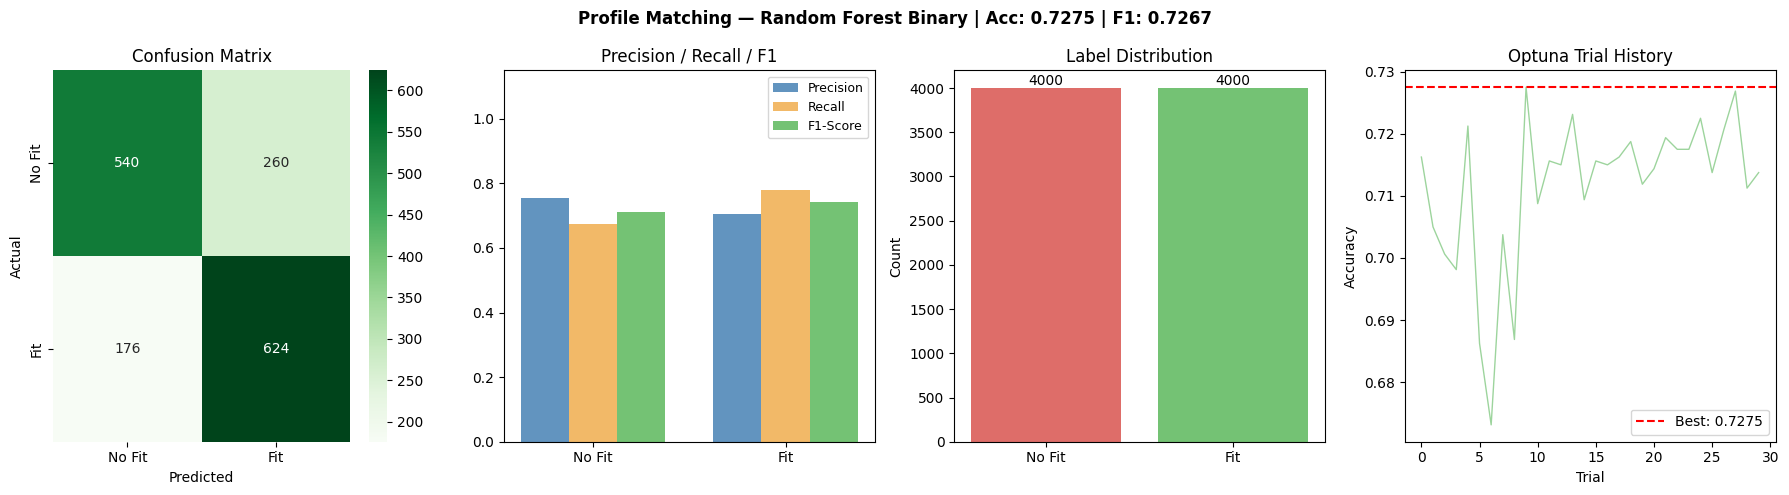

In [ ]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig)

ax1 = fig.add_subplot(gs[0])
sns.heatmap(confusion_matrix(y_te_match, y_pred_match), annot=True, fmt="d",
            cmap="Greens", ax=ax1,
            xticklabels=["No Fit","Fit"], yticklabels=["No Fit","Fit"])
ax1.set_title("Confusion Matrix"); ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")

ax2 = fig.add_subplot(gs[1])
classes = ["No Fit","Fit"]
x = np.arange(len(classes)); w = 0.25
ax2.bar(x-w, [report_match[c]["precision"] for c in classes], w, label="Precision", color="steelblue",  alpha=0.85)
ax2.bar(x,   [report_match[c]["recall"]    for c in classes], w, label="Recall",    color="#f0ad4e",    alpha=0.85)
ax2.bar(x+w, [report_match[c]["f1-score"]  for c in classes], w, label="F1-Score",  color="#5cb85c", alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(classes, fontsize=10)
ax2.set_title("Precision / Recall / F1"); ax2.set_ylim(0, 1.15); ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[2])
lc = pd.Series(y_match).value_counts().sort_index()
ax3.bar(["No Fit","Fit"], lc.values, color=["#d9534f","#5cb85c"], alpha=0.85)
ax3.set_title("Label Distribution"); ax3.set_ylabel("Count")
for bar, val in zip(ax3.patches, lc.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
             str(val), ha="center", fontsize=10)

ax4 = fig.add_subplot(gs[3])
trial_vals = [t.value for t in study_match.trials]
ax4.plot(trial_vals, color="#5cb85c", alpha=0.6, linewidth=1)
ax4.axhline(study_match.best_value, color="red", linestyle="--",
            label=f"Best: {study_match.best_value:.4f}")
ax4.set_title("Optuna Trial History"); ax4.set_xlabel("Trial"); ax4.set_ylabel("Accuracy"); ax4.legend()

plt.suptitle(f"Profile Matching — Random Forest Binary | Acc: {acc_match:.4f} | F1: {report_match['weighted avg']['f1-score']:.4f}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "match_rf_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. ATS Scoring — Random Forest Classifier

In [ ]:
def ats_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 5, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": SEED,
        "n_jobs": -1,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_tr_ats_bal, y_tr_ats_bal)
    return accuracy_score(y_te_ats, model.predict(X_te_ats))

study_ats = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_ats.optimize(ats_objective, n_trials=CFG.optuna_trials)

best_ats_params = study_ats.best_params
best_ats_params.update({"random_state": SEED, "n_jobs": -1,})

ats_model = RandomForestClassifier(**best_ats_params)
ats_model.fit(X_tr_ats_bal, y_tr_ats_bal)

y_pred_ats  = ats_model.predict(X_te_ats)
acc_ats     = accuracy_score(y_te_ats, y_pred_ats)
report_ats  = classification_report(
    y_te_ats, y_pred_ats,
    target_names=["Low ATS","Medium ATS","High ATS"],
    output_dict=True
)

sep = "=" * 58
print(sep)
print("  ATS SCORING — Random Forest Classifier (3-class)")
print(sep)
print(f"  Train size  : {len(X_tr_ats_bal)} (after SMOTE)")
print(f"  Test size   : {len(X_te_ats)}")
print(f"  Features    : {X_te_ats.shape[1]} (rule-based)")
print(f"  Best params : {best_ats_params}")
print(sep)
print(f"  Accuracy    : {acc_ats:.4f}")
print(f"  Macro F1    : {report_ats['macro avg']['f1-score']:.4f}")
print(f"  Macro Prec  : {report_ats['macro avg']['precision']:.4f}")
print(f"  Macro Recall: {report_ats['macro avg']['recall']:.4f}")
print(f"  Weighted F1 : {report_ats['weighted avg']['f1-score']:.4f}")
print(sep)
rows_ats = []
for label in ["Low ATS","Medium ATS","High ATS"]:
    r = report_ats[label]
    rows_ats.append([label, f"{r['precision']:.4f}", f"{r['recall']:.4f}",
                     f"{r['f1-score']:.4f}", int(r['support'])])
print(tabulate(rows_ats,
               headers=["Class","Precision","Recall","F1-Score","Support"],
               tablefmt="rounded_outline"))

joblib.dump(ats_model,         MODEL_DIR / "ats_scorer_rf.pkl")
joblib.dump(ATS_LABEL,         MODEL_DIR / "ats_label_map.pkl")
joblib.dump(feature_names_ats, MODEL_DIR / "ats_feature_names.pkl")
print("\nSaved: ats_scorer_rf.pkl")

  ATS SCORING — Random Forest Classifier (3-class)
  Train size  : 6156 (after SMOTE)
  Test size   : 1020
  Features    : 16 (rule-based)
  Best params : {'n_estimators': 445, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42, 'n_jobs': -1}
  Accuracy    : 0.4686
  Macro F1    : 0.4292
  Macro Prec  : 0.4290
  Macro Recall: 0.4302
  Weighted F1 : 0.4723
╭────────────┬─────────────┬──────────┬────────────┬───────────╮
│ Class      │   Precision │   Recall │   F1-Score │   Support │
├────────────┼─────────────┼──────────┼────────────┼───────────┤
│ Low ATS    │       0.617 │   0.5809 │     0.5984 │       513 │
│ Medium ATS │       0.348 │   0.3725 │     0.3598 │       255 │
│ High ATS   │       0.322 │   0.3373 │     0.3295 │       252 │
╰────────────┴─────────────┴──────────┴────────────┴───────────╯

Saved: ats_scorer_rf.pkl


## 13. ATS Scoring — Visualization

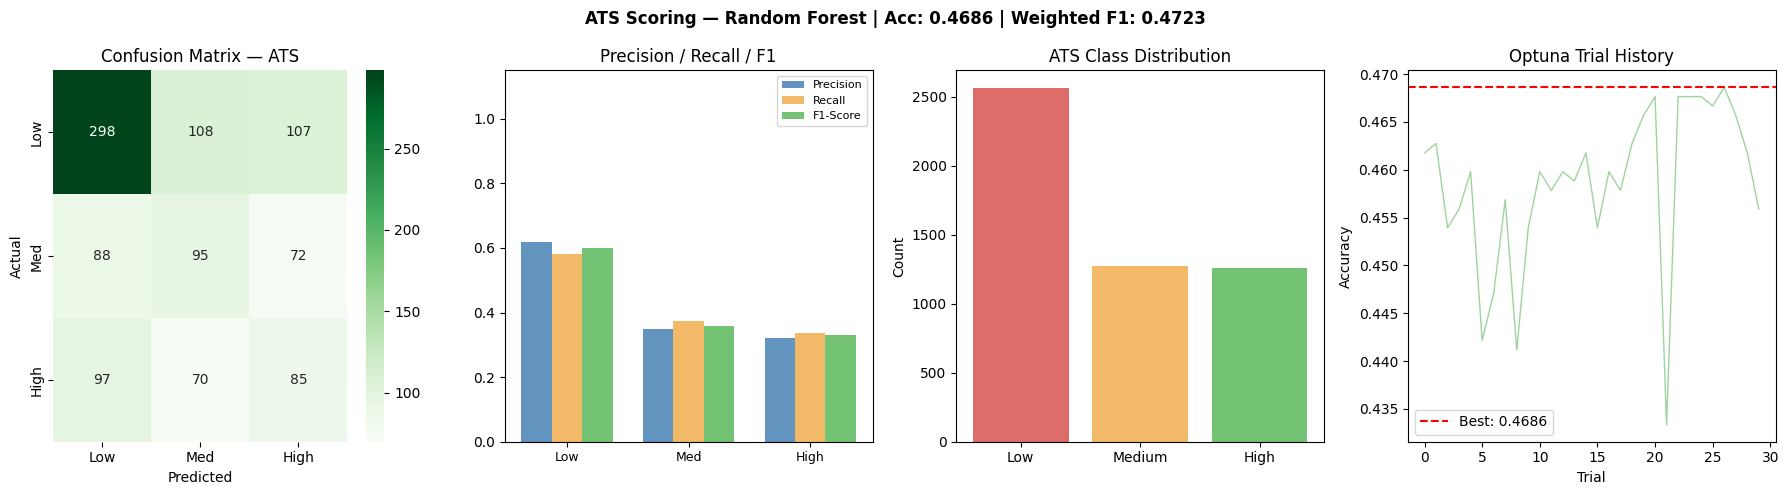

In [ ]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig)

ax1 = fig.add_subplot(gs[0])
sns.heatmap(confusion_matrix(y_te_ats, y_pred_ats), annot=True, fmt="d",
            cmap="Greens", ax=ax1,
            xticklabels=["Low","Med","High"], yticklabels=["Low","Med","High"])
ax1.set_title("Confusion Matrix — ATS"); ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")

ax2 = fig.add_subplot(gs[1])
classes_ats = ["Low ATS","Medium ATS","High ATS"]
x = np.arange(len(classes_ats)); w = 0.25
ax2.bar(x-w, [report_ats[c]["precision"] for c in classes_ats], w, label="Precision", color="steelblue", alpha=0.85)
ax2.bar(x,   [report_ats[c]["recall"]    for c in classes_ats], w, label="Recall",    color="#f0ad4e",   alpha=0.85)
ax2.bar(x+w, [report_ats[c]["f1-score"]  for c in classes_ats], w, label="F1-Score",  color="#5cb85c",   alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(["Low","Med","High"], fontsize=9)
ax2.set_title("Precision / Recall / F1"); ax2.set_ylim(0, 1.15); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[2])
cc = pd.Series(y_ats).value_counts().sort_index()
ax3.bar(["Low","Medium","High"], cc.values, color=["#d9534f","#f0ad4e","#5cb85c"], alpha=0.85)
ax3.set_title("ATS Class Distribution"); ax3.set_ylabel("Count")

ax4 = fig.add_subplot(gs[3])
trial_vals = [t.value for t in study_ats.trials]
ax4.plot(trial_vals, color="#5cb85c", alpha=0.6, linewidth=1)
ax4.axhline(study_ats.best_value, color="red", linestyle="--",
            label=f"Best: {study_ats.best_value:.4f}")
ax4.set_title("Optuna Trial History"); ax4.set_xlabel("Trial"); ax4.set_ylabel("Accuracy"); ax4.legend()

plt.suptitle(f"ATS Scoring — Random Forest | Acc: {acc_ats:.4f} | Weighted F1: {report_ats['weighted avg']['f1-score']:.4f}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "ats_rf_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Section Scoring — Random Forest Multi-output Regressor

In [ ]:
def section_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": SEED,
        "n_jobs": -1,
    }
    model = RandomForestRegressor(**params)
    model.fit(X_tr_sec, y_tr_sec)
    preds = model.predict(X_te_sec)
    maes = [mean_absolute_error(y_te_sec[:, i], preds[:, i])
            for i in range(y_te_sec.shape[1])]
    return -np.mean(maes)

study_section = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_section.optimize(section_objective, n_trials=CFG.optuna_trials, timeout=600)

best_sec_params = study_section.best_params
best_sec_params.update({"random_state": SEED, "n_jobs": -1})

section_model = RandomForestRegressor(**best_sec_params)
section_model.fit(X_tr_sec, y_tr_sec)

y_pred_sec = section_model.predict(X_te_sec)
section_metrics = {}
rows = []
for i, col in enumerate(TARGET_COLS):
    mae = mean_absolute_error(y_te_sec[:, i], y_pred_sec[:, i])
    rmse = np.sqrt(mean_squared_error(y_te_sec[:, i], y_pred_sec[:, i]))
    r2 = r2_score(y_te_sec[:, i], y_pred_sec[:, i])
    mape = float(np.mean(np.abs(
        (y_te_sec[:, i] - y_pred_sec[:, i]) / np.clip(np.abs(y_te_sec[:, i]), 1e-8, None)
    )) * 100)
    section_metrics[col] = {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}
    rows.append([col.replace("score_", "").capitalize(),
                 f"{mae:.4f}", f"{rmse:.4f}", f"{r2:.4f}", f"{mape:.2f}%"])

sep = "=" * 58
print(sep)
print("  SECTION SCORING — Random Forest Multi-output Regressor")
print(sep)
print(f"  Train size  : {len(X_tr_sec)}")
print(f"  Test size   : {len(X_te_sec)}")
print(f"  Features    : {X_te_sec.shape[1]} (PCA {CFG.pca_components}d + 10 explicit)")
print(f"  Best params : {best_sec_params}")
print(sep)
print(tabulate(rows,
               headers=["Section", "MAE", "RMSE", "R2", "MAPE"],
               tablefmt="rounded_outline"))

joblib.dump(section_model, MODEL_DIR / "section_scorer_rf.pkl")
joblib.dump(TARGET_COLS, MODEL_DIR / "section_target_cols.pkl")
print("\nSaved: section_scorer_rf.pkl")


  SECTION SCORING — Random Forest Multi-output Regressor
  Train size  : 6400
  Test size   : 1600
  Features    : 138 (PCA 128d + 10 explicit)
  Best params : {'n_estimators': 485, 'max_depth': 25, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}
╭────────────┬────────┬────────┬────────┬────────╮
│ Section    │    MAE │   RMSE │     R2 │ MAPE   │
├────────────┼────────┼────────┼────────┼────────┤
│ Experience │ 0.0675 │ 0.0865 │ 0.5852 │ inf%   │
│ Skills     │ 0.0593 │ 0.0755 │ 0.5671 │ 11.31% │
│ Education  │ 0.0824 │ 0.1038 │ 0.4361 │ 20.30% │
│ Overall    │ 0.0379 │ 0.0545 │ 0.8229 │ inf%   │
╰────────────┴────────┴────────┴────────┴────────╯

Saved: section_scorer_rf.pkl


## 15. Section Scoring — Visualization

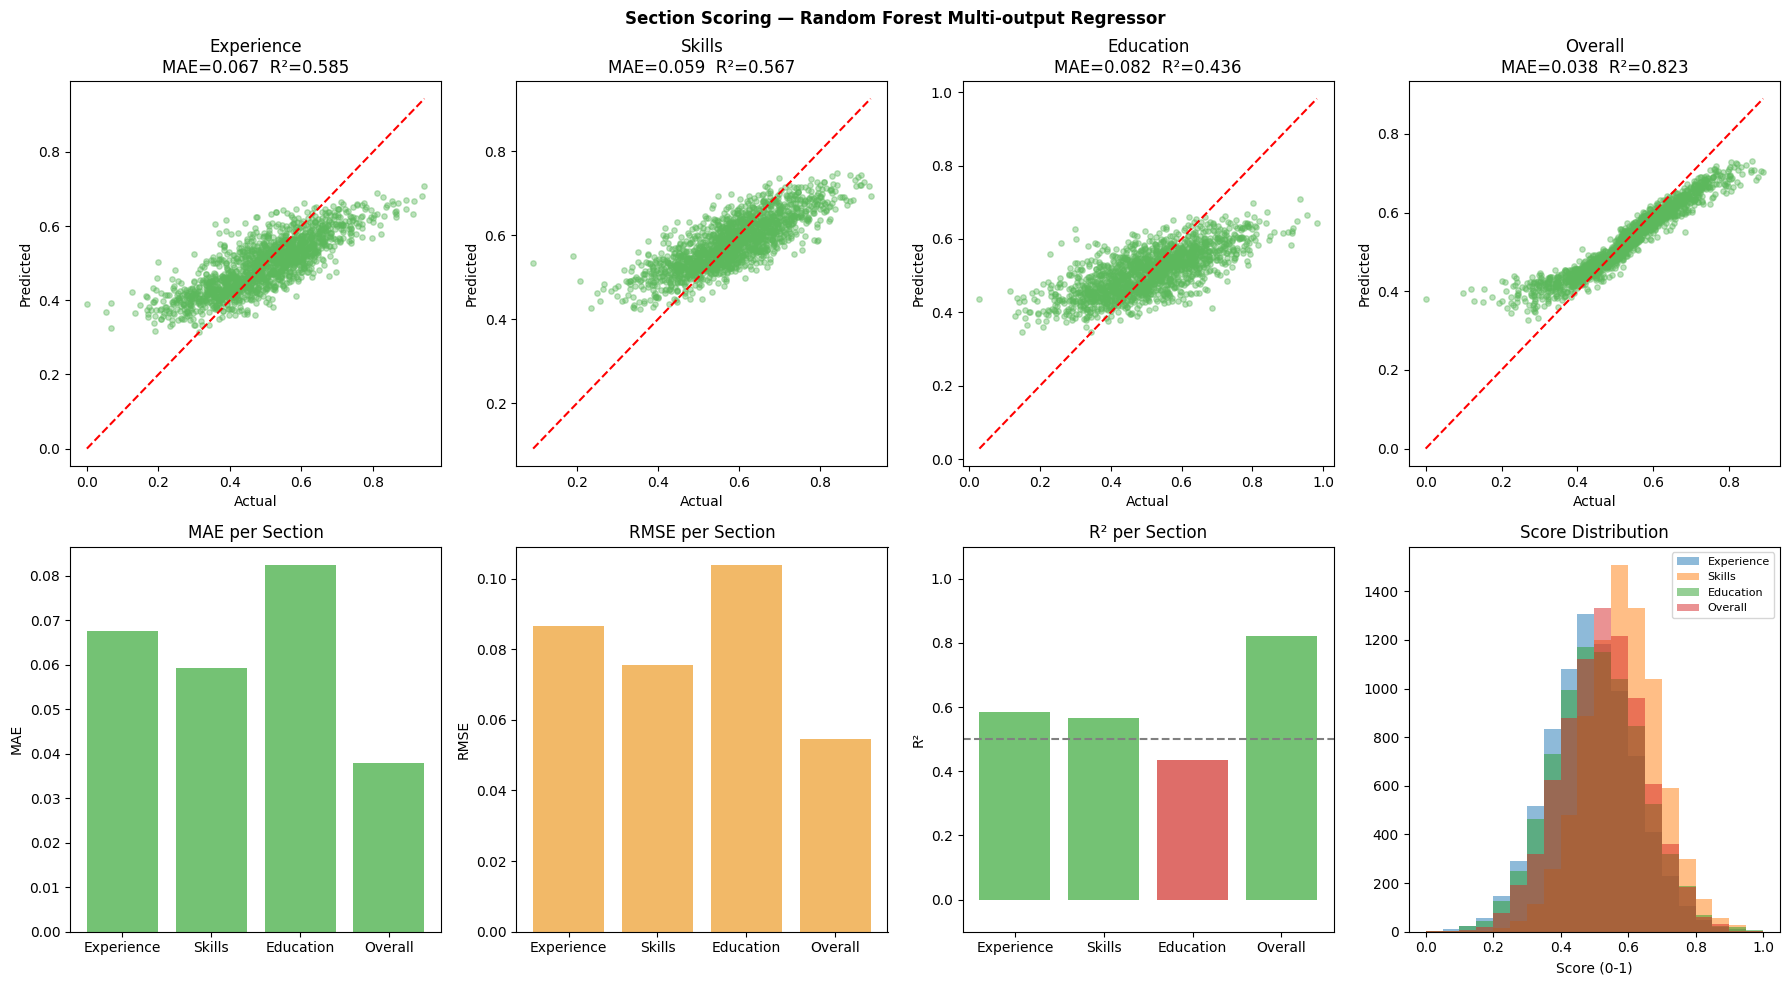

In [ ]:
section_labels = [c.replace("score_","").capitalize() for c in TARGET_COLS]
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig)

for i, (col, label) in enumerate(zip(TARGET_COLS, section_labels)):
    ax = fig.add_subplot(gs[0, i])
    ax.scatter(y_te_sec[:, i], y_pred_sec[:, i], alpha=0.4, s=15, color="#5cb85c")
    mn = min(y_te_sec[:, i].min(), y_pred_sec[:, i].min())
    mx = max(y_te_sec[:, i].max(), y_pred_sec[:, i].max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5)
    m = section_metrics[col]
    ax.set_title(f"{label}\nMAE={m['MAE']:.3f}  R²={m['R2']:.3f}")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")

ax5 = fig.add_subplot(gs[1, 0])
ax5.bar(section_labels, [section_metrics[c]["MAE"] for c in TARGET_COLS],
        color="#5cb85c", alpha=0.85)
ax5.set_title("MAE per Section"); ax5.set_ylabel("MAE")

ax6 = fig.add_subplot(gs[1, 1])
ax6.bar(section_labels, [section_metrics[c]["RMSE"] for c in TARGET_COLS],
        color="#f0ad4e", alpha=0.85)
ax6.set_title("RMSE per Section"); ax6.set_ylabel("RMSE")

ax7 = fig.add_subplot(gs[1, 2])
r2s = [section_metrics[c]["R2"] for c in TARGET_COLS]
ax7.bar(section_labels, r2s,
        color=["#5cb85c" if v >= 0.5 else "#d9534f" for v in r2s], alpha=0.85)
ax7.axhline(0.5, color="gray", linestyle="--")
ax7.set_title("R² per Section"); ax7.set_ylabel("R²"); ax7.set_ylim(-0.1, 1.1)

ax8 = fig.add_subplot(gs[1, 3])
for i, (col, label) in enumerate(zip(TARGET_COLS, section_labels)):
    ax8.hist(y_section[:, i], bins=20, alpha=0.5, label=label)
ax8.set_title("Score Distribution"); ax8.set_xlabel("Score (0-1)"); ax8.legend(fontsize=8)

plt.suptitle("Section Scoring — Random Forest Multi-output Regressor",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "section_rf_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Full Metrics Summary

  TRAINING SUMMARY — Random Forest Model
  Embedding      : nomic-ai/nomic-embed-text-v1 (zero-shot)
  PCA components : 128
  Explicit feats : 10 (keyword overlap, ratios, presence flags)
  Split          : 80/20 | seed=42
  Tuning         : Optuna (30 trials per model)
╭──────────────────┬──────────────────────────────────────┬──────────────────┬──────────────────────────────────────╮
│ Task             │ Algorithm                            │ Primary Metric   │ Other Metrics                        │
├──────────────────┼──────────────────────────────────────┼──────────────────┼──────────────────────────────────────┤
│ Profile Matching │ Random Forest Classifier (Binary)    │ Acc=0.7275       │ F1=0.7267 | Prec=0.7300 | Rec=0.7275 │
│ ATS Scoring      │ Random Forest Classifier (3-class)   │ Acc=0.4686       │ F1=0.4723 | Prec=0.4290 | Rec=0.4302 │
│ Section Scoring  │ Random Forest Multi-output Regressor │ MAE=0.0379       │ RMSE=0.0545 | R²=0.8229              │
╰──────────────────┴─

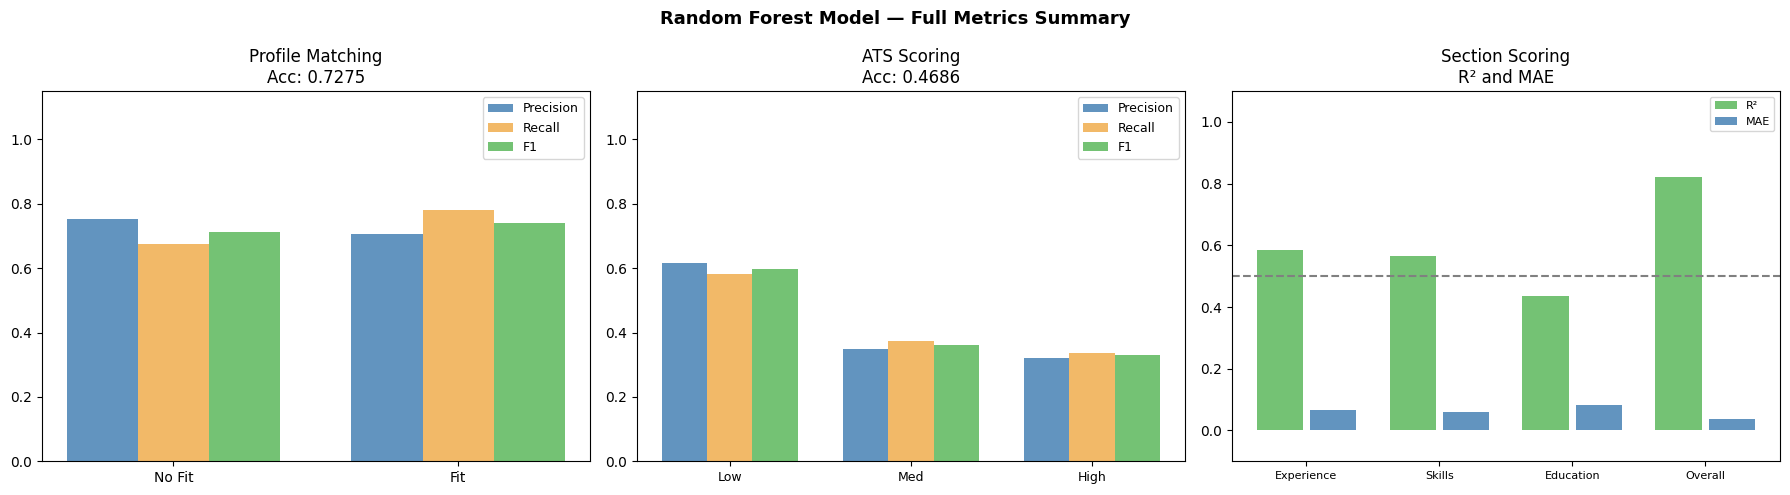

Saved: rf_summary.png


In [ ]:
sep = "=" * 70
print(sep)
print("  TRAINING SUMMARY — Random Forest Model")
print(sep)
print(f"  Embedding      : nomic-ai/nomic-embed-text-v1 (zero-shot)")
print(f"  PCA components : {CFG.pca_components}")
print(f"  Explicit feats : 10 (keyword overlap, ratios, presence flags)")
print(f"  Split          : 80/20 | seed={SEED}")
print(f"  Tuning         : Optuna ({CFG.optuna_trials} trials per model)")
print(sep)

section_labels = [c.replace("score_","").capitalize() for c in TARGET_COLS]
summary_rows = [
    ["Profile Matching", "Random Forest Classifier (Binary)",
     f"Acc={acc_match:.4f}",
     f"F1={report_match['weighted avg']['f1-score']:.4f} | "
     f"Prec={report_match['macro avg']['precision']:.4f} | "
     f"Rec={report_match['macro avg']['recall']:.4f}"],
    ["ATS Scoring", "Random Forest Classifier (3-class)",
     f"Acc={acc_ats:.4f}",
     f"F1={report_ats['weighted avg']['f1-score']:.4f} | "
     f"Prec={report_ats['macro avg']['precision']:.4f} | "
     f"Rec={report_ats['macro avg']['recall']:.4f}"],
    ["Section Scoring", "Random Forest Multi-output Regressor",
     f"MAE={section_metrics['score_overall']['MAE']:.4f}",
     f"RMSE={section_metrics['score_overall']['RMSE']:.4f} | "
     f"R²={section_metrics['score_overall']['R2']:.4f}"],
]
print(tabulate(summary_rows,
               headers=["Task","Algorithm","Primary Metric","Other Metrics"],
               tablefmt="rounded_outline"))

print()
print("  Per-class — Profile Matching")
print(tabulate(rows_cls,
               headers=["Class","Precision","Recall","F1-Score","Support"],
               tablefmt="rounded_outline"))

print()
print("  Per-class — ATS Scoring")
print(tabulate(rows_ats,
               headers=["Class","Precision","Recall","F1-Score","Support"],
               tablefmt="rounded_outline"))

print()
print("  Per-section — Section Scoring")
print(tabulate(rows,
               headers=["Section","MAE","RMSE","R²","MAPE"],
               tablefmt="rounded_outline"))

print()
file_rows = []
for f in sorted(MODEL_DIR.glob("*.pkl")):
    file_rows.append([f.name, f"{f.stat().st_size/1024:.1f} KB"])
print(tabulate(file_rows, headers=["File","Size"], tablefmt="rounded_outline"))
print(sep)

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0])
classes = ["No Fit","Fit"]
x = np.arange(len(classes)); w = 0.25
ax1.bar(x-w, [report_match[c]["precision"] for c in classes], w, label="Precision", color="steelblue", alpha=0.85)
ax1.bar(x,   [report_match[c]["recall"]    for c in classes], w, label="Recall",    color="#f0ad4e",   alpha=0.85)
ax1.bar(x+w, [report_match[c]["f1-score"]  for c in classes], w, label="F1",        color="#5cb85c",   alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(classes, fontsize=10)
ax1.set_title(f"Profile Matching\nAcc: {acc_match:.4f}")
ax1.set_ylim(0, 1.15); ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[1])
classes_ats = ["Low ATS","Medium ATS","High ATS"]
x2 = np.arange(len(classes_ats))
ax2.bar(x2-w, [report_ats[c]["precision"] for c in classes_ats], w, label="Precision", color="steelblue", alpha=0.85)
ax2.bar(x2,   [report_ats[c]["recall"]    for c in classes_ats], w, label="Recall",    color="#f0ad4e",   alpha=0.85)
ax2.bar(x2+w, [report_ats[c]["f1-score"]  for c in classes_ats], w, label="F1",        color="#5cb85c",   alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(["Low","Med","High"], fontsize=9)
ax2.set_title(f"ATS Scoring\nAcc: {acc_ats:.4f}")
ax2.set_ylim(0, 1.15); ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[2])
r2s      = [section_metrics[c]["R2"]  for c in TARGET_COLS]
mae_vals = [section_metrics[c]["MAE"] for c in TARGET_COLS]
x3 = np.arange(len(section_labels))
ax3.bar(x3-0.2, r2s,      0.35, label="R²",  color="#5cb85c",   alpha=0.85)
ax3.bar(x3+0.2, mae_vals,  0.35, label="MAE", color="steelblue", alpha=0.85)
ax3.set_xticks(x3); ax3.set_xticklabels(section_labels, fontsize=8)
ax3.axhline(0.5, color="gray", linestyle="--")
ax3.set_title("Section Scoring\nR² and MAE"); ax3.set_ylim(-0.1, 1.1); ax3.legend(fontsize=8)

plt.suptitle("Random Forest Model — Full Metrics Summary", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "rf_summary.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: rf_summary.png")

## 17. Inference Helper

In [ ]:
def grade_score(score: float) -> str:
    if score >= CFG.grade_excellent: return "excellent"
    if score >= CFG.grade_good:      return "good"
    if score >= CFG.grade_fair:      return "fair"
    return "bad"

def predict_match(cv_text: str, profile_text: str) -> dict:
    emb_cv  = encoder.encode([f"search_document: {cv_text}"],  normalize_embeddings=True)[0]
    emb_job = encoder.encode([f"search_query: {profile_text}"], normalize_embeddings=True)[0]
    explicit = extract_explicit_features(cv_text, profile_text)
    raw      = np.hstack([[np.dot(emb_cv, emb_job)],
                           np.abs(emb_cv - emb_job), emb_cv * emb_job])
    feat     = np.hstack([pca_match.transform(raw.reshape(1, -1))[0],
                           explicit]).reshape(1, -1)
    proba    = match_model.predict_proba(feat)[0]
    pred     = int(proba.argmax())
    if proba.max() < CFG.match_confidence_threshold:
        pred = 0
    return {
        "match_label":      MATCH_LABEL[pred],
        "match_confidence": round(float(proba.max()), 4),
        "match_score":      round(float(np.dot(emb_cv, emb_job)), 4),
    }

def predict_ats(cv_text: str) -> dict:
    feats = extract_ats_features(cv_text)
    x     = np.array([feats[n] for n in feature_names_ats]).reshape(1, -1)
    pred  = int(ats_model.predict(x)[0])
    proba = ats_model.predict_proba(x)[0]
    return {
        "ats_label":      ATS_LABEL[pred],
        "ats_confidence": round(float(proba.max()), 4),
    }

def predict_sections(cv_text: str, profile_text: str) -> dict:
    emb_cv  = encoder.encode([f"search_document: {cv_text}"],  normalize_embeddings=True)[0]
    emb_job = encoder.encode([f"search_query: {profile_text}"], normalize_embeddings=True)[0]
    explicit = extract_explicit_features(cv_text, profile_text)
    raw      = np.hstack([[np.dot(emb_cv, emb_job)],
                           np.abs(emb_cv - emb_job), emb_cv * emb_job])
    feat     = np.hstack([pca_section.transform(raw.reshape(1, -1))[0],
                           explicit]).reshape(1, -1)
    preds    = section_model.predict(feat)[0]
    return {
        col.replace("score_",""): round(float(np.clip(p, 0, 1)) * 100, 1)
        for col, p in zip(TARGET_COLS, preds)
    }

def run_full_analysis(cv_text: str, profile_text: str) -> dict:
    match_res   = predict_match(cv_text, profile_text)
    ats_res     = predict_ats(cv_text)
    section_res = predict_sections(cv_text, profile_text)
    ats_score   = (100 if ats_res["ats_label"] == "High ATS" else
                   50  if ats_res["ats_label"] == "Medium ATS" else 20)
    overall     = round(
        section_res["overall"] * CFG.weight_section_overall +
        ats_score * CFG.weight_ats, 1
    )
    return {
        "overall_score":  overall,
        "grade":          grade_score(overall),
        "match":          match_res,
        "ats":            ats_res,
        "section_scores": section_res,
    }

TEST_CV = (
    "John Doe | john@email.com | +1-555-123-4567\n"
    "Summary: Software engineer with 5 years experience in Python, FastAPI, and React.\n"
    "Skills: Python, FastAPI, React, PostgreSQL, Docker, Git\n"
    "Experience: Backend Engineer at TechCorp 2020-2024. Built REST APIs serving 50k users.\n"
    "  Reduced latency by 30% through caching optimization.\n"
    "Education: B.Sc Computer Science, MIT, 2020"
)
TEST_PROFILE = (
    "Looking for a backend engineer with Python and FastAPI experience. "
    "Must know REST API design, databases, and cloud deployment."
)
result = run_full_analysis(TEST_CV, TEST_PROFILE)
print(json.dumps(result, indent=2))

{
  "overall_score": 49.8,
  "grade": "fair",
  "match": {
    "match_label": "Fit",
    "match_confidence": 0.6407,
    "match_score": 0.7402
  },
  "ats": {
    "ats_label": "Low ATS",
    "ats_confidence": 0.46
  },
  "section_scores": {
    "experience": 63.7,
    "skills": 70.3,
    "education": 63.0,
    "overall": 69.6
  }
}


## 18. Download Models

In [ ]:
import shutil
from google.colab import files
zip_path = "cv_analysis_rf_models.zip"
shutil.make_archive("cv_analysis_rf_models", "zip", MODEL_DIR)
size_mb = Path(zip_path).stat().st_size / 1024 / 1024
print(f"Archive: {zip_path}  ({size_mb:.1f} MB)")
files.download(zip_path)

Archive: cv_analysis_rf_models.zip  (63.7 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>